## Exploración inicial

#### Pequeño experimento previo

Antes de entrar de lleno a trabajar con los datos verídicos, hacemos un pequeño experimento visual del porque es aconsejable trabajar con rendimientos logarítmicos.

1. Vemos como los rendimientos logarítmicos cumplen aditividad, mientras los simples no.
2. Se observa como en un caso de rendimiento nulo, el rendimiento logarítimico es simetrico ya que nos devuelve 0 como rendimiento, mientras el simple no lo es.

In [ ]:
import numpy as np

# Precios inventados de prueba
precios = np.array([100.0, 105.0, 99.75, 108.0, 102.60])

# Rendimientos simples y logarítmicos
simple = precios[1:] / precios[:-1] - 1
log_r  = np.log(precios[1:]) - np.log(precios[:-1])

print("Rendimientos simples :", np.round(simple, 6))
print("Rendimientos log     :", np.round(log_r,  6))

# --- Aditividad ---
total_real = precios[-1] / precios[0] - 1
print("\nRendimiento total real           :", round(total_real, 6))
print("Suma de los simples (INCORRECTO) :", round(simple.sum(), 6))
print("exp(suma de los log) - 1 (BIEN)  :", round(np.exp(log_r.sum()) - 1, 6))

# --- Simetría ---
precios_2 = np.array([100.0, 150.0, 100.0])
simple_2 = precios_2[1:] / precios_2[:-1] - 1
log_2 = np.diff(np.log(precios_2))
print("\n100 -> 150 -> 100")
print("simples:", np.round(simple_2, 4), " suma:", round(simple_2.sum(), 4))
print("log    :", np.round(log_2, 4), " suma:", round(log_2.sum(), 4))

Rendimientos simples : [ 0.05     -0.05      0.082707 -0.05    ]
Rendimientos log     : [ 0.04879  -0.051293  0.079464 -0.051293]

Rendimiento total real           : 0.026
Suma de los simples (INCORRECTO) : 0.032707
exp(suma de los log) - 1 (BIEN)  : 0.026

100 -> 150 -> 100
simples: [ 0.5    -0.3333]  suma: 0.1667
log    : [ 0.4055 -0.4055]  suma: 0.0


## Carga de datos

Primero de todo necesitamos ejecutar ciertas funciones del archivo data.py desde este notebook. Como no estan al mismo nivel, necesitamos subir a la raíz del proyecto para poder cargar dichas funciones.

Finalmente ejecutamos la funcion cargar_precios

In [1]:
# Jupyter arranca en notebooks/, así que Python no ve el paquete src/.

import sys
from pathlib import Path

# Añadimos la raíz del proyecto a la ruta de búsqueda de módulos.
RAIZ = Path.cwd().parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.data import cargar_precios

precios = cargar_precios()
precios.tail()

[data] Caché local: GSPC_2000-01-01_2026-09-01.csv


,Close,High,Low,Open,Volume
Date,,,,,
2026-08-25,7677.279785,7686.109863,7650.919922,7676.660156,4260240000
2026-08-26,7675.700195,7690.729980,7657.410156,7666.879883,4100600000
2026-08-27,7730.990234,7741.270020,7689.890137,7710.339844,4362240000
2026-08-28,7711.759766,7771.479980,7700.910156,7735.169922,4297560000
2026-08-31,7686.140137,7697.520020,7665.060059,7697.520020,5386090000


Observamos como los datos no contienen niguna anomalia. El número de filas es correcto, ya uqe equivalandrían a unas 252 sesiones por año. El rango es correcto, sin duplicados y sin NaN. 

In [2]:
print("Filas:", len(precios))
print("Rango:", precios.index.min().date(), "→", precios.index.max().date())
print("Índice ordenado:", precios.index.is_monotonic_increasing)
print("Fechas duplicadas:", precios.index.has_duplicates)
print("NaN por columna:\n", precios.isna().sum())
print("\nSesiones por año:\n", precios.index.year.value_counts().sort_index())

Filas: 6705
Rango: 2000-01-03 → 2026-08-31
Índice ordenado: True
Fechas duplicadas: False
NaN por columna:
 Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Sesiones por año:
 Date
2000    252
2001    248
2002    252
2003    252
2004    252
2005    252
2006    251
2007    251
2008    253
2009    252
2010    252
2011    252
2012    250
2013    252
2014    252
2015    252
2016    252
2017    251
2018    251
2019    252
2020    253
2021    252
2022    251
2023    250
2024    252
2025    250
2026    166
Name: count, dtype: int64


## Construcción del dataset

Llamamos a la función construir_dataset  y hacemos un head para mostrar el dataframe obtenido.

In [4]:
from src.features import construir_dataset

df = construir_dataset()
df.head()

[data] Caché local: GSPC_2000-01-01_2026-09-01.csv
[features] 6705 filas -> 6678 tras eliminar NaN
[features] Guardado en C:\Users\Victor\Desktop\Victor\Matematicas\neuro-fuzzy-volatility-forecasting\data\processed\dataset.csv


c:\Users\Victor\Desktop\Victor\Matematicas\neuro-fuzzy-volatility-forecasting\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,close,r,rv_1,rv_5,rv_22,ret_5,y,log_rv_1,log_rv_5,log_rv_22,log_y
Date,,,,,,,,,,,
2000-02-03,1424.969971,0.011185,0.177562,0.286819,0.249093,0.018708,0.174558,-1.728436,-1.248903,-1.389930,-1.745500
2000-02-04,1424.369995,-0.000421,0.006685,0.207867,0.211041,0.046127,0.230427,-5.007847,-1.570857,-1.555705,-1.467820
2000-02-07,1424.239990,-0.000091,0.001449,0.109309,0.210941,0.021131,0.230877,-6.536908,-2.213577,-1.556178,-1.465870
2000-02-08,1441.719971,0.012198,0.193645,0.117539,0.214919,0.022758,0.222705,-1.641728,-2.140988,-1.537496,-1.501909
2000-02-09,1411.709961,-0.021035,0.333922,0.190041,0.207543,0.001836,0.180702,-1.096847,-1.660517,-1.572416,-1.710905


#### Partición del dataset

Se observan los intervalos seleccionados con el número de registros para cada uno.
Además se corrobora que no tenemos fuga de información, y por lo tanto estamos listos para empezar nuestro modelo.

In [5]:
from src.splits import particionar, normalizar, verificar_sin_fuga

partes = particionar(df)
verificar_sin_fuga(partes)
partes_norm, est = normalizar(partes)

[splits] train  :  3998 filas  (2000-02-03 → 2015-12-23)
[splits] val    :  1001 filas  (2016-01-04 → 2019-12-23)
[splits] test   :  1669 filas  (2020-01-02 → 2026-08-24)
[splits] estres :    52 filas  (2020-02-18 → 2020-04-30)
[splits] Sin fuga. Huecos de 12 y 10 días naturales en las fronteras.


c:\Users\Victor\Desktop\Victor\Matematicas\neuro-fuzzy-volatility-forecasting\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Guardamos el siguiente output como resumen de lo consgeuido hasta este punto.

- Intervalos de la partición, con la volatilidad media de cada uno. Notese la partición estres
- Absencia de nulos y medias normalizadas. Que no sea 0 en cada partición corrobora que no hemos normalizado cada conjunto por separado

In [6]:
import pandas as pd

# Tabla resumen de la partición
resumen = pd.DataFrame({
    nombre: {
        "filas": len(p),
        "desde": p.index.min().date(),
        "hasta": p.index.max().date(),
        "vol. media": round(p["y"].mean(), 4),
    }
    for nombre, p in partes.items()
}).T
print(resumen, "\n")

# Media y desviación tras normalizar: train debe dar ~0 y ~1;
# val y test NO, y eso es lo correcto (usan los estadísticos de train).
for nombre in ["train", "val", "test"]:
    m = partes_norm[nombre][["log_rv_1", "log_rv_5", "log_rv_22"]].mean()
    print(f"{nombre}: medias normalizadas = {m.round(3).values}")

       filas       desde       hasta vol. media
train   3998  2000-02-03  2015-12-23     0.1639
val     1001  2016-01-04  2019-12-23     0.1064
test    1669  2020-01-02  2026-08-24     0.1601
estres    52  2020-02-18  2020-04-30     0.5911 

train: medias normalizadas = [nan -0.  0.]
val: medias normalizadas = [   nan -0.735 -0.783]
test: medias normalizadas = [   nan -0.034 -0.009]


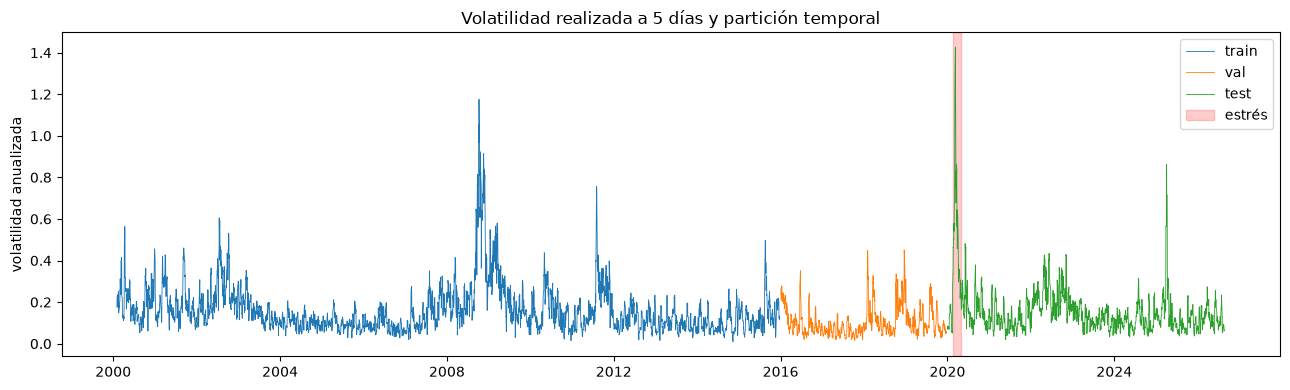

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 4))
colores = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green"}
for nombre, color in colores.items():
    p = partes[nombre]
    ax.plot(p.index, p["y"], color=color, lw=0.6, label=nombre)

e = partes["estres"]
ax.axvspan(e.index.min(), e.index.max(), color="red", alpha=0.2, label="estrés")
ax.set_title("Volatilidad realizada a 5 días y partición temporal")
ax.set_ylabel("volatilidad anualizada")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/particion_temporal.png", dpi=150)
plt.show()